# Preprocessed Frame Check

Pick one random `.npy` file from `data/processed`, visualize it, and run a few basic sanity checks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd()
processed_dir = cwd / "data" / "processed"
if not processed_dir.exists():
    processed_dir = cwd.parent / "data" / "processed"

files = sorted(processed_dir.glob("*.npy"))
assert files, f"No .npy files found in {processed_dir.resolve()}"

print(f"Found {len(files)} preprocessed files in {processed_dir.resolve()}")

Found 1152 preprocessed files in /home/imaayush/code/cloudDiffusion/data/processed


In [2]:
rng = np.random.default_rng()
sample_path = rng.choice(files)
frame = np.load(sample_path)

stats = {
    "file": sample_path.name,
    "shape": frame.shape,
    "dtype": str(frame.dtype),
    "min": float(frame.min()),
    "max": float(frame.max()),
    "mean": float(frame.mean()),
    "std": float(frame.std()),
    "finite_fraction": float(np.isfinite(frame).mean()),
    "zero_fraction": float((frame == 0).mean()),
}

for key, value in stats.items():
    print(f"{key}: {value}")

assert frame.ndim == 2, f"Expected a 2D frame, got shape {frame.shape}"
assert frame.size > 0, "Frame is empty"
assert np.isfinite(frame).all(), "Frame contains NaN or inf values"
assert frame.min() >= 0.0, f"Frame min is below 0: {frame.min()}"
assert frame.max() <= 1.0, f"Frame max is above 1: {frame.max()}"
assert frame.std() > 0.0, "Frame has no variation"

print("Sanity checks passed.")

file: OR_ABI-L1b-RadC-M6C13_G16_s20231852116183_e20231852118568_c20231852119041.npy
shape: (256, 256)
dtype: float32
min: 0.32670852541923523
max: 0.8970805406570435
mean: 0.693183958530426
std: 0.16935047507286072
finite_fraction: 1.0
zero_fraction: 0.0
Sanity checks passed.


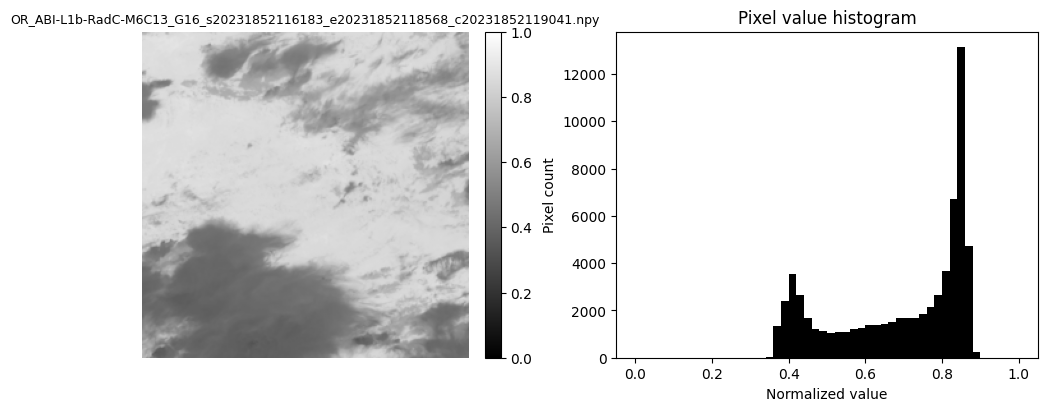

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

image = axes[0].imshow(frame, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(sample_path.name, fontsize=9)
axes[0].axis("off")
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].hist(frame.ravel(), bins=50, range=(0, 1), color="black")
axes[1].set_title("Pixel value histogram")
axes[1].set_xlabel("Normalized value")
axes[1].set_ylabel("Pixel count")

plt.show()